In [16]:
import pandas as pd 
import numpy as np 
import re
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

# Looking for a numer of clusters

In [2]:
out_path = r"../data/df_with_embedding.csv"

In [4]:
df = pd.read_csv(out_path)

In [5]:
df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,body_length,answer_length,tags_combined,embedding
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,security,outage,disruption,data breach,NaN,NaN,NaN,NaN,741,634,security outage disruption data breach,[-1.03392359e-02 2.63129957e-02 -2.84555107e-...
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,account,disruption,outage,it,tech support,NaN,NaN,NaN,534,488,account disruption outage it tech support,[-7.26402700e-02 -5.49703138e-03 3.76073383e-...
2,query about smart home system integration feat...,dear customer support team n ni hope this mess...,thank you for your inquiry our products suppor...,Request,Returns and Exchanges,medium,en,51,product,feature,tech support,NaN,NaN,NaN,NaN,NaN,526,494,product feature tech support,[-2.93684416e-02 6.26825020e-02 8.22922867e-...
3,inquiry regarding invoice details,dear customer support team n ni hope this mess...,we appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,billing,payment,account,documentation,feedback,NaN,NaN,NaN,593,532,billing payment account documentation feedback,[-0.07255821 -0.02554824 0.01098065 0.022927...
4,question about marketing agency software compa...,dear support team n ni hope this message reach...,thank you for your inquiry our product support...,Problem,Sales and Pre-Sales,medium,en,51,product,feature,feedback,tech support,NaN,NaN,NaN,NaN,667,268,product feature feedback tech support,[-0.0356531 0.03832313 -0.02116072 0.016278...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28582,performance problem with data analytics tool,the data analytics tool experiences sluggish p...,we are addressing the performance issue with t...,Incident,Technical Support,high,en,400,performance,it,tech support,NaN,NaN,NaN,NaN,NaN,74,266,performance it tech support,[-8.99049863e-02 4.73823622e-02 -2.38774065e-...
28583,datensperrung in der kundschaftsbetreuung,es gab einen datensperrungsunfall bei dem unge...,ich kann ihnen bei dem datensperrungsunfall he...,Incident,Product Support,high,de,400,security,it,tech support,bug,NaN,NaN,NaN,NaN,406,397,security it tech support bug,[-1.86050422e-02 2.18552668e-02 -5.50524564e-...
28584,problem mit der videokonferenz-software heute,wichtigere sitzungen wurden unterbrochen durch...,sehr geehrte r name leider wurde das problem m...,Incident,Human Resources,low,de,400,bug,performance,network,it,tech support,NaN,NaN,NaN,235,579,bug performance network it tech support,[-7.43740574e-02 8.21817480e-03 -5.96467815e-...
28585,update request for saas platform integration f...,requesting an update on the integration featur...,received your request for updates on the integ...,Change,IT Support,high,en,400,feature,it,tech support,NaN,NaN,NaN,NaN,NaN,281,264,feature it tech support,[-0.04219642 0.01103642 -0.01116476 0.019883...


In [6]:
def fix_emb_spaces(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').strip()      # убрать переносы строк
        x = x.strip('[]')                     # убрать []
        x = x.split()                         # разбить по пробелам
        return np.array([float(n) for n in x], dtype=np.float32)
    return np.array(x, dtype=np.float32)

df['embedding'] = df['embedding'].apply(fix_emb_spaces)
X = np.vstack(df['embedding'].values)


In [7]:


# Преобразуем embeddings в numpy матрицу if нужно
X = np.vstack(df['embedding'].values)

k_values = list(range(10, 26))

inertias = []
sil_scores = []
ch_scores = []

for k in k_values:
    print(f"Training KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

print("Done!")


Training KMeans for k=10...
Training KMeans for k=11...
Training KMeans for k=12...
Training KMeans for k=13...
Training KMeans for k=14...
Training KMeans for k=15...
Training KMeans for k=16...
Training KMeans for k=17...
Training KMeans for k=18...
Training KMeans for k=19...
Training KMeans for k=20...
Training KMeans for k=21...
Training KMeans for k=22...
Training KMeans for k=23...
Training KMeans for k=24...
Training KMeans for k=25...
Done!


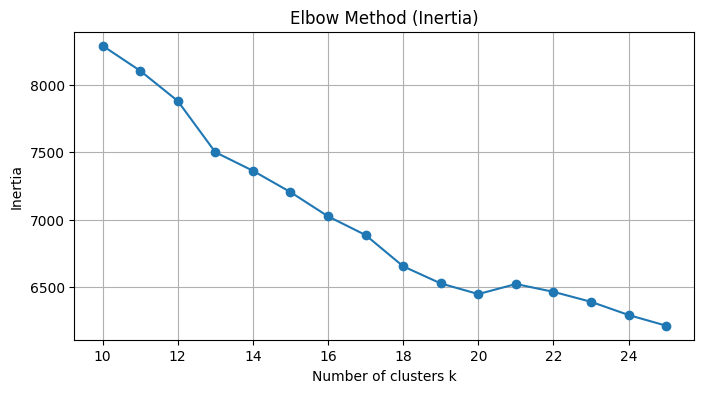

In [8]:
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

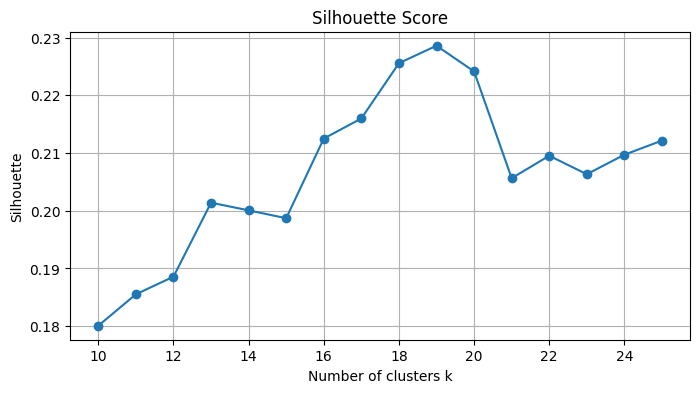

In [9]:
plt.figure(figsize=(8,4))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()


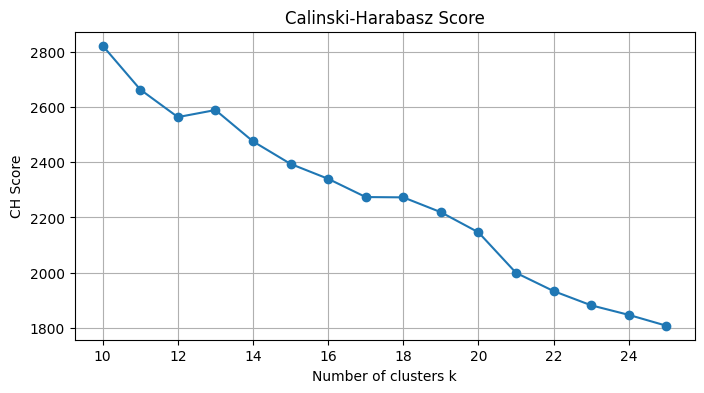

In [10]:
plt.figure(figsize=(8,4))
plt.plot(k_values, ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("Number of clusters k")
plt.ylabel("CH Score")
plt.grid(True)
plt.show()

# Clusterring

In [11]:
n_clusters = 19

In [12]:
X = np.vstack(df['embedding'].values)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [13]:
display(df[['tags_combined', 'cluster']].head(10))

,tags_combined,cluster
0,security outage disruption data breach,7
1,account disruption outage it tech support,11
2,product feature tech support,16
3,billing payment account documentation feedback,5
4,product feature feedback tech support,16
5,feature product documentation feedback,4
6,outage disruption performance it tech support,11
7,network hardware performance bug compatibility,6
8,documentation feedback it tech support,15
9,disruption outage recovery support,17


In [ ]:
out_path = r"../data/df_with_embedding_and_clusters.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_embedding_and_clusters.csv


## Name of clusters

In [14]:
df.groupby('cluster')['tags_combined'].apply(lambda x: x.sample(10))

cluster       
0        6581                    disruption network it tech support
         805                    network hardware disruption support
         23604           outage network performance it tech support
         3204        network disruption performance it tech support
         13120              bug network performance it tech support
                                        ...                        
18       981      feature feedback data analysis financial servi...
         9872     feature scalability documentation software bus...
         1554     product documentation support integration scal...
         8285     documentation support integration workflow onb...
         9717     tech support integration workflow automation i...
Name: tags_combined, Length: 190, dtype: object

In [17]:
def top_words(tags, n=15):
    words = []
    for t in tags:
        t = re.sub(r"[^a-zA-Z ]", " ", t.lower())
        words.extend(t.split())
    return Counter(words).most_common(n)


In [ ]:
cluster_groups = (
    df.groupby("cluster")['tags_combined']
    .apply(list)
    .sort_index()
)

In [19]:
cluster_groups

cluster
0     [network disruption vpn tech support, bug cras...
1     [marketing feedback sales lead, product docume...
2     [account security compatibility tech support, ...
3     [video hardware performance compatibility tech...
4     [feature product documentation feedback, refun...
5     [billing payment account documentation feedbac...
6     [network hardware performance bug compatibilit...
7     [security outage disruption data breach, secur...
8     [feature account marketing performance automat...
9     [sales lead feedback marketing customer suppor...
10    [network connectivity performance security har...
11    [account disruption outage it tech support, ou...
12    [it tech support performance feature documenta...
13    [product service feedback sales, product featu...
14    [product documentation security it, compliance...
15    [documentation feedback it tech support, docum...
16    [product feature tech support, product feature...
17    [disruption outage recovery suppor

In [20]:
for cid, tags in cluster_groups.items():
    print("="*80)
    print(f"CLUSTER {cid}")
    print("Tags count:", len(tags))
    print("Top words:", top_words(tags, n=10))
    print("Example tags:", tags[:12])
    print()


CLUSTER 0
Tags count: 2403
Top words: [('network', 2397), ('support', 2394), ('tech', 2326), ('it', 2132), ('performance', 2105), ('bug', 894), ('disruption', 889), ('outage', 480), ('hardware', 277), ('security', 136)]
Example tags: ['network disruption vpn tech support', 'bug crash network performance disruption outage tech support', 'network disruption hardware tech support', 'network performance disruption it tech support', 'network disruption connectivity tech support', 'product hardware network disruption support', 'network performance outage disruption tech support', 'network disruption connectivity tech support', 'disruption service product network cloud it tech support', 'network outage disruption hardware tech support', 'network disruption connectivity tech support', 'network hardware it tech support']

CLUSTER 1
Tags count: 713
Top words: [('feedback', 692), ('sales', 681), ('documentation', 568), ('feature', 336), ('lead', 146), ('marketing', 139), ('product', 103), ('perfo

# Mapping

In [22]:
cluster_mapping = {
    0:  "Network Disruptions & Connectivity Issues",
    1:  "Sales & Marketing Feedback",
    2:  "Security Support Requests",
    3:  "Performance & Bug-Related Tech Issues",
    4:  "Documentation Feedback",
    5:  "Billing & Payment Issues",
    6:  "Software Maintenance & Troubleshooting",
    7:  "Data Privacy & Healthcare Compliance",
    8:  "Marketing Strategy & Campaigns",
    9:  "Sales Support Feedback",
    10: "Security Outages & Incident Response",
    11: "IT Outage Support & Recovery",
    12: "Documentation + Bug Fixing",
    13: "Product Feature Feedback",
    14: "Security Documentation & Compliance",
    15: "Feature Documentation Support",     # ❶ Документация + Feature + Support
    16: "Feature Support Requests",          # ❷ Feature-heavy Support
    17: "Outage Recovery & Maintenance",
    18: "Integration & Analytics",
}

In [23]:
df['cluster_name'] = df['cluster'].map(cluster_mapping)

In [ ]:
out_path = r"../data/df_with_cluster_name.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_cluster_name.csv
